Kanzada(Zhumakan)Nurkamil kyzy

User Acquisition Analysis

Loading & Cleaning Data

In [2]:
import pandas as pd
import numpy as np
cust_data = pd.read_csv(r"C:\Users\kanza\Downloads\User-Acquisition-Analysis\data\customer_signups.csv")
#Checking for the null values for each category
print(cust_data.isnull().sum())

customer_id          2
name                 9
email               34
signup_date          2
source               9
region              30
plan_selected        8
marketing_opt_in    10
age                 12
gender               8
dtype: int64


In [3]:
#Filling the null value, created 
#Data filled with values are legit for the dataset
#For example filling email with the example email is it legit for the data accuracy, naming them does not influece to the analysis 
#For the analis filling themm with legit informatin considered the right choice
#Do not lose date, for the data consistency
cust_data = cust_data.fillna({
    'email':'noemail@example.com',
    'signup_date':pd.NaT,
    'source':'Google',
    'region':'Nowth', # assuming north is the mode in the dataset
    'plan_selected':'Basic', #assuming basic is the default plan
    'marketing_opt_in': 'Yes',
    'age': 0,
    'gender':'Not Specified',
})

In [4]:
#dropping the null values for the name column, since the name requires the unique values 
cust_data.dropna(subset = 'name', inplace=True)

In [5]:
#Checking the dataset for the needed information
cust_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 291 entries, 0 to 299
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       289 non-null    object
 1   name              291 non-null    object
 2   email             291 non-null    object
 3   signup_date       289 non-null    object
 4   source            291 non-null    object
 5   region            291 non-null    object
 6   plan_selected     291 non-null    object
 7   marketing_opt_in  291 non-null    object
 8   age               291 non-null    object
 9   gender            291 non-null    object
dtypes: object(10)
memory usage: 25.0+ KB


Feature Engineering -Data Preparation

In [6]:
#Data is not consistent, converting the data type to the right date type, signup data was non in the date type
#Non-standardized values of the plan selected, gender converted to the capitalize letters 
cust_data["signup_date"] = pd.to_datetime(cust_data["signup_date"], dayfirst=True, errors='coerce')
cust_data["plan_selected"] = cust_data["plan_selected"].str.strip().str.capitalize()
cust_data["gender"] = cust_data["gender"].str.strip().str.capitalize()
print(cust_data.head())


  customer_id             name                 email signup_date     source  \
0   CUST00000    Joshua Bryant   noemail@example.com         NaT  Instagram   
1   CUST00001   Nicole Stewart   nicole1@example.com  2024-01-02   LinkedIn   
2   CUST00002     Rachel Allen   rachel2@example.com  2024-01-03     Google   
3   CUST00003  Zachary Sanchez  zachary3@mailhub.org  2024-01-04    YouTube   
5   CUST00005    John Gonzales     john5@mailhub.org  2024-01-06   Facebook   

  region plan_selected marketing_opt_in age      gender  
0  Nowth         Basic               No  34      Female  
1   West         Basic              Yes  29        Male  
2  North       Premium              Yes  34  Non-binary  
3  Nowth           Pro               No  40        Male  
5  South       Premium               No  34       Other  


C:\Users\kanza\AppData\Local\Temp\ipykernel_2244\3801735649.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cust_data["signup_date"] = pd.to_datetime(cust_data["signup_date"], dayfirst=True, errors='coerce')


In [7]:
#The customer id was not dropping since there were missing values, filled with the index numbers, since the customer id matches with the index number
#Using apply method was replaced the values
new_id = {
    161: 'CUST00161',
    287: 'CUST00287',
}
cust_data['customer_id'] = cust_data.apply(lambda row: new_id[row.name] if row.name in new_id else row['customer_id'], axis=1)

In [8]:
#After cleaning checking for the null values
print("Number of missing for columns:" , cust_data.isnull().sum())

Number of missing for columns: customer_id         0
name                0
email               0
signup_date         5
source              0
region              0
plan_selected       0
marketing_opt_in    0
age                 0
gender              0
dtype: int64


Data preprocessing

In [9]:
#Calculating % for the missing values
missing_pct = (cust_data.isna().sum() / len(cust_data)) * 100
print(missing_pct)

customer_id         0.000000
name                0.000000
email               0.000000
signup_date         1.718213
source              0.000000
region              0.000000
plan_selected       0.000000
marketing_opt_in    0.000000
age                 0.000000
gender              0.000000
dtype: float64


In [10]:
#Replacing non standartized values
cust_data['source'] = cust_data['source'].replace('??', 'Google')
cust_data['age'] = cust_data['age'].replace({'unknown': '0', 'thirty': '30', '206': '20'}).astype(int)
cust_data['gender'] = cust_data['gender'].replace({'Non-binary': 'Not specified', '123': 'Not specified', 'Other': 'Not specified'})
cust_data['plan_selected'] = cust_data['plan_selected'].replace({'Prem': 'Premium'})
cust_data['region'] = cust_data['region'].replace({'Nowth': 'North'})

Data aggregation

In [11]:
#Finding weekly sings up
signups_per_week = cust_data.set_index("signup_date").resample("W").size()
print(signups_per_week)

signup_date
2024-01-07    5
2024-01-14    7
2024-01-21    7
2024-01-28    7
2024-02-04    7
2024-02-11    6
2024-02-18    7
2024-02-25    7
2024-03-03    7
2024-03-10    7
2024-03-17    7
2024-03-24    6
2024-03-31    6
2024-04-07    7
2024-04-14    6
2024-04-21    7
2024-04-28    7
2024-05-05    6
2024-05-12    7
2024-05-19    6
2024-05-26    7
2024-06-02    7
2024-06-09    6
2024-06-16    6
2024-06-23    7
2024-06-30    7
2024-07-07    7
2024-07-14    7
2024-07-21    6
2024-07-28    7
2024-08-04    7
2024-08-11    6
2024-08-18    6
2024-08-25    7
2024-09-01    6
2024-09-08    7
2024-09-15    7
2024-09-22    7
2024-09-29    7
2024-10-06    7
2024-10-13    7
2024-10-20    7
2024-10-27    6
dtype: int64


In [12]:
#Sing up by sourses, region and plan selected
signup_counts = cust_data.groupby(['source', 'region', 'plan_selected'])['customer_id'].size()
signup_counts.head(15)


source    region   plan_selected
Facebook  Central  Premium          4
                   Pro              3
          East     Basic            3
                   Premium          3
                   Pro              4
          North    Basic            2
                   Premium          4
                   Pro              8
          South    Basic            2
                   Premium          4
                   Pro              1
          West     Premium          1
                   Pro              1
Google    Central  Basic            2
                   Premium          2
Name: customer_id, dtype: int64

In [13]:
#The numbers for each plan
cust_data['plan_selected'].value_counts()

plan_selected
Basic          98
Premium        95
Pro            93
Unknownplan     5
Name: count, dtype: int64

In [14]:
#Marketing opt in by the gender
cust_data.groupby('gender')['marketing_opt_in'].value_counts()

gender         marketing_opt_in
Female         No                  46
               Yes                 46
Male           No                  50
               Yes                 38
               Nil                  1
Not specified  No                  55
               Yes                 55
Name: count, dtype: int64

In [15]:
#Age summary of the customers
age_summary = cust_data['age'].agg(['mean', 'median', 'min', 'max'])
print(age_summary)



mean      33.340206
median    34.000000
min        0.000000
max       60.000000
Name: age, dtype: float64


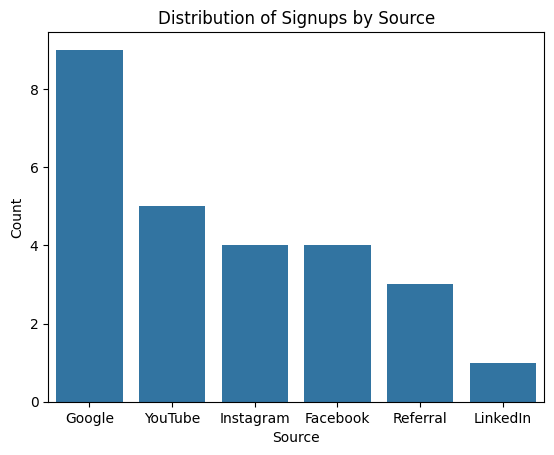

In [16]:
#Number of signups by source for the last month
import seaborn as sns
import matplotlib.pyplot as plt
last_month = cust_data[cust_data['signup_date'].dt.to_period('M') == cust_data['signup_date'].dt.to_period('M').max()]
source_order = last_month['source'].value_counts().index
sns.countplot(data=last_month, x='source', order=source_order)
plt.title('Distribution of Signups by Source')
plt.xlabel('Source')
plt.ylabel('Count') 
plt.show()

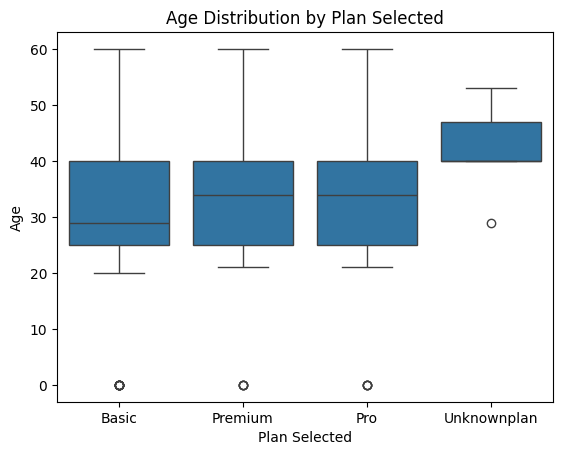

In [17]:
#Age distribution by plan selected
sns.boxplot(data=cust_data, x='plan_selected', y='age')
plt.title('Age Distribution by Plan Selected')
plt.xlabel('Plan Selected')
plt.ylabel('Age')
plt.show()

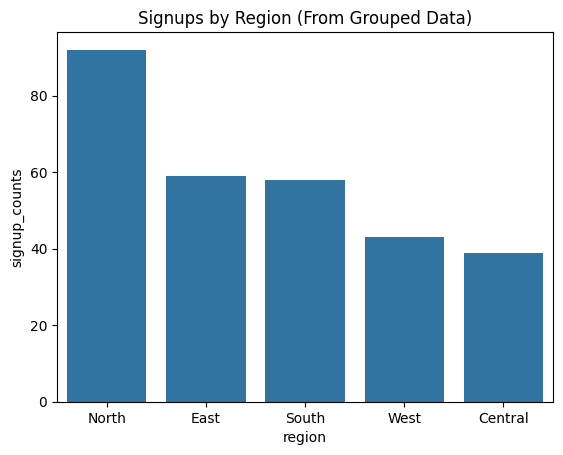

In [18]:
#Number of signups by region for the last month
# 1. Perform the calculation and reset the index to create columns
signup_summary = cust_data.groupby('region').size().reset_index(name='signup_counts')
signup_summary = signup_summary.sort_values('signup_counts', ascending= False)
sns.barplot(data=signup_summary, x='region', y='signup_counts', order=signup_summary['region'])
plt.title('Signups by Region (From Grouped Data)')
plt.show()

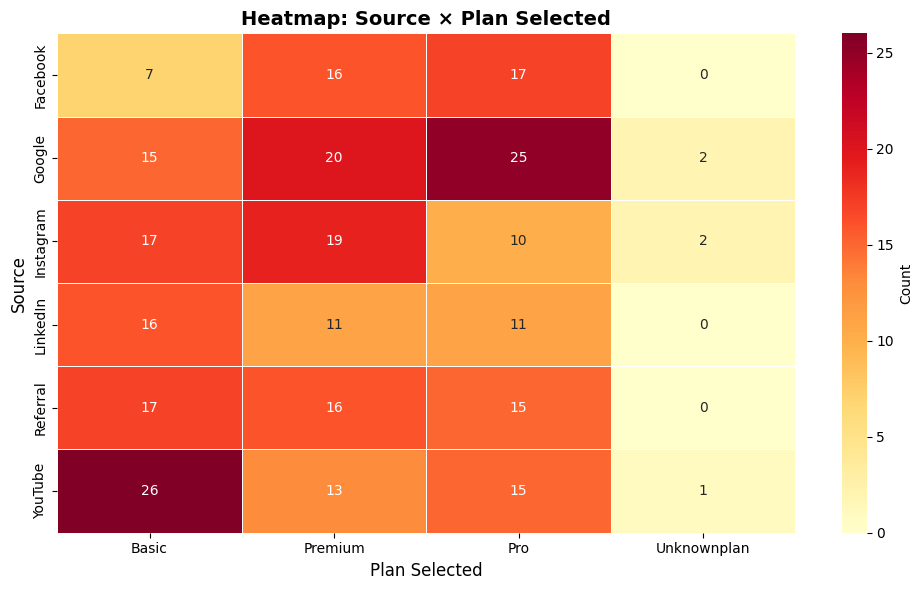

In [19]:
# Heatmap: source × plan_selected their relationship, the count of customers for each combination of source and plan selected
source_plan = cust_data.groupby(['source', 'plan_selected']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(source_plan, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Count'})
plt.title('Heatmap: Source × Plan Selected', fontsize=14, fontweight='bold')
plt.xlabel('Plan Selected', fontsize=12)
plt.ylabel('Source', fontsize=12)
plt.tight_layout()
plt.show()

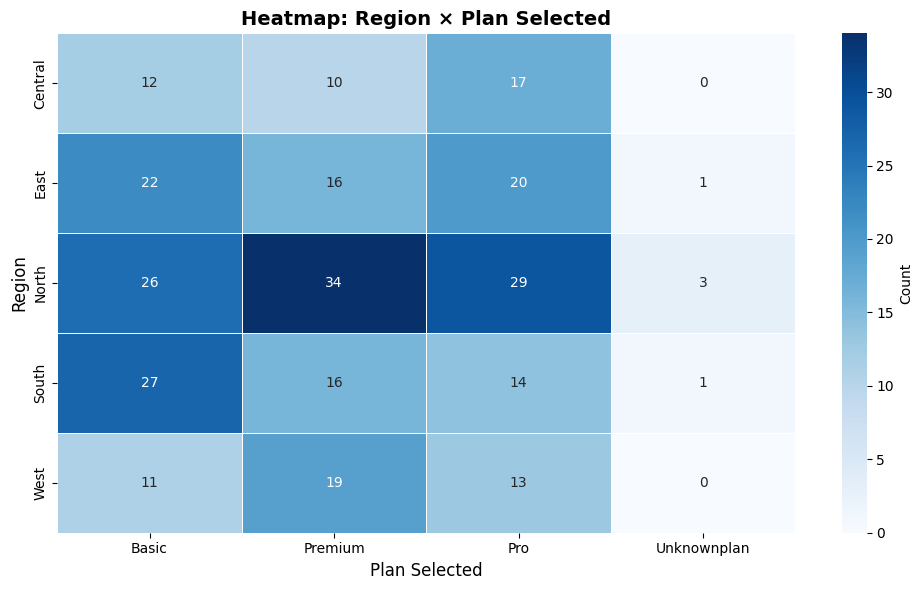

In [20]:
# Heatmap: region × plan_selected and their relationship, the count of customers for each combination of region and plan selected
region_plan = cust_data.groupby(['region', 'plan_selected']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(region_plan, annot=True, fmt='d', cmap='Blues', linewidths=0.5, cbar_kws={'label': 'Count'})
plt.title('Heatmap: Region × Plan Selected', fontsize=14, fontweight='bold')
plt.xlabel('Plan Selected', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Age Distribution by Plan Selected')

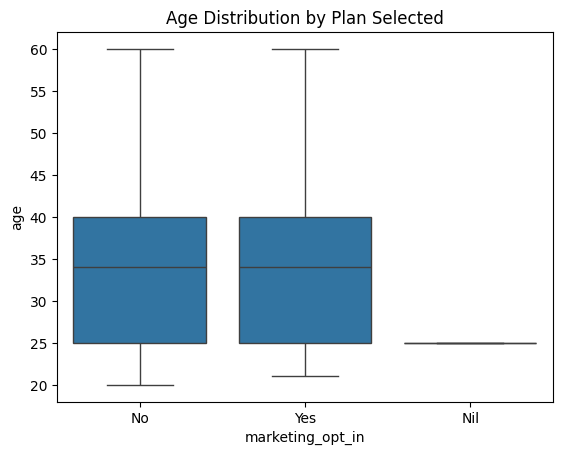

In [21]:
#Age distribution by marketing opt in
clean_age = cust_data[cust_data['age'] > 0]
sns.boxplot(data=clean_age, x='marketing_opt_in', y='age')
plt.title('Age Distribution by Plan Selected')


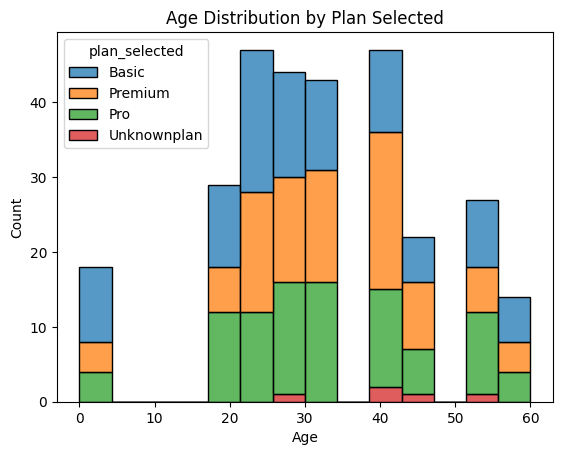

In [22]:
#Age distribution by plan selected
sns.histplot(cust_data, x='age', hue='plan_selected', multiple='stack')
plt.title('Age Distribution by Plan Selected')  
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

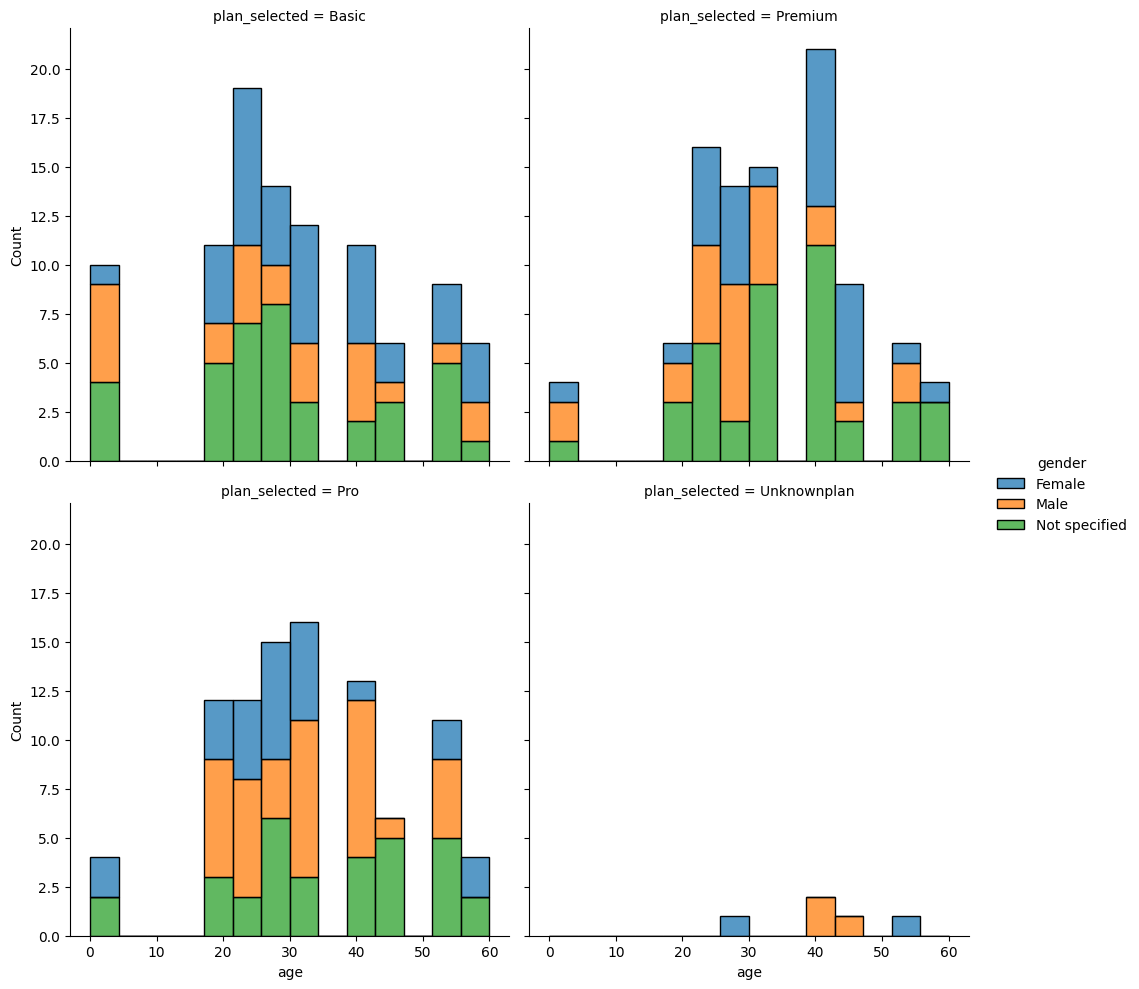

In [23]:

# Using col='plan_selected' creates a separate chart for each plan side-by-side
sns.displot(
    data=cust_data, 
    x='age', 
    hue='gender', 
    col='plan_selected', 
    multiple='stack', 
    kind='hist',
    col_wrap=2  # This puts 2 charts per row so they aren't too small
)

plt.show()

C:\Users\kanza\AppData\Local\Temp\ipykernel_2244\2515726604.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sns.lineplot(data=cust_data.set_index('signup_date').resample('M').size())


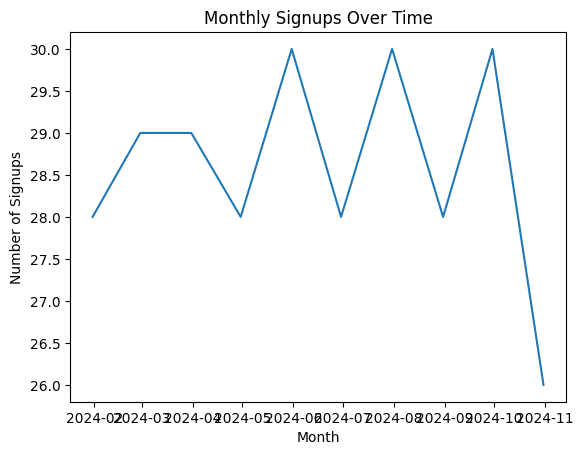

In [24]:
#Monthly signups over time 
sns.lineplot(data=cust_data.set_index('signup_date').resample('M').size())
plt.title('Monthly Signups Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Signups')
plt.show()

Clean data

In [25]:
cust_data.to_csv(r"C:\Users\kanza\Downloads\User-Acquisition-Analysis\data\cleaned_customer_signups.csv", index=False)